In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
from torchvision import datasets, transforms

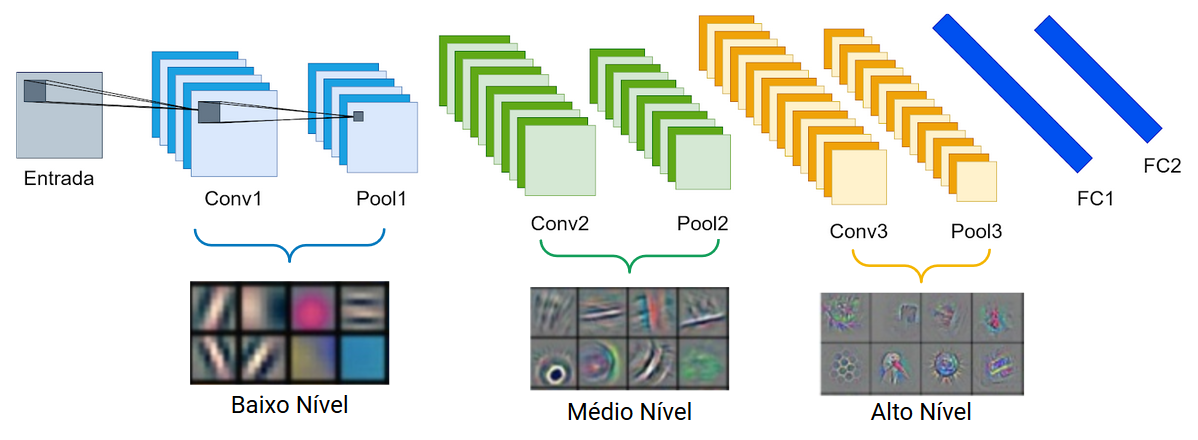

In [ ]:
MNIST = datasets.MNIST('./data', train=False, download=True,
                       transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.62MB/s]


In [ ]:
dado, rotulo = MNIST[0]
print(type(dado), type(rotulo))
print(dado.size(), rotulo)
#dataset com apenas 1 canal de cor

<class 'torch.Tensor'> <class 'int'>
torch.Size([1, 28, 28]) 7


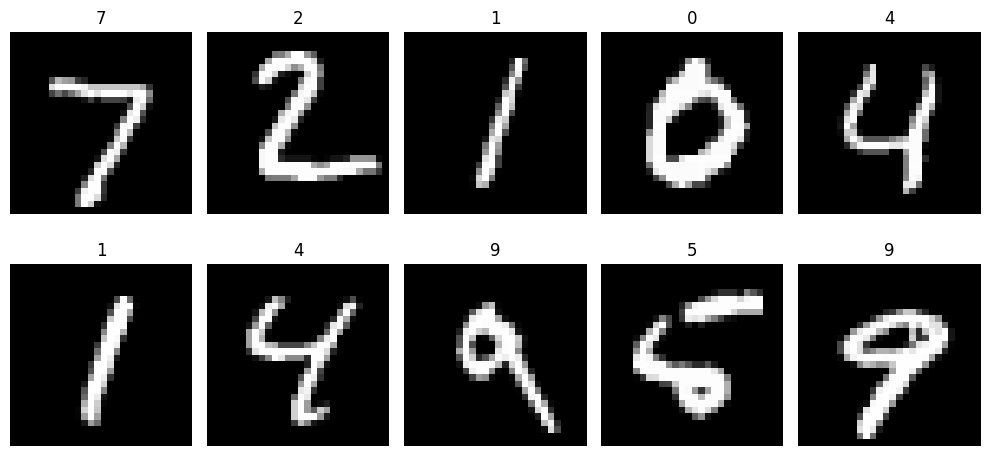

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    dado, rotulo = MNIST[i]
    axs[i // 5, i % 5].imshow(dado[0], cmap='gray')
    axs[i // 5, i % 5].set_title(str(rotulo))
    axs[i // 5, i % 5].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
coco = datasets.VOCDetection('./data',
                            image_set='train', download=True,
                            transform=transforms.ToTensor())

In [ ]:
dado, rotulo = coco[0]
print(type(dado), type(rotulo))
print(dado.size(), rotulo)

<class 'torch.Tensor'> <class 'dict'>
torch.Size([3, 442, 500]) {'annotation': {'folder': 'VOC2012', 'filename': '2008_000008.jpg', 'source': {'database': 'The VOC2008 Database', 'annotation': 'PASCAL VOC2008', 'image': 'flickr'}, 'size': {'width': '500', 'height': '442', 'depth': '3'}, 'segmented': '0', 'object': [{'name': 'horse', 'pose': 'Left', 'truncated': '0', 'occluded': '1', 'bndbox': {'xmin': '53', 'ymin': '87', 'xmax': '471', 'ymax': '420'}, 'difficult': '0'}, {'name': 'person', 'pose': 'Unspecified', 'truncated': '1', 'occluded': '0', 'bndbox': {'xmin': '158', 'ymin': '44', 'xmax': '289', 'ymax': '167'}, 'difficult': '0'}]}}


Dimensionalidade: torch.Size([3, 442, 500])


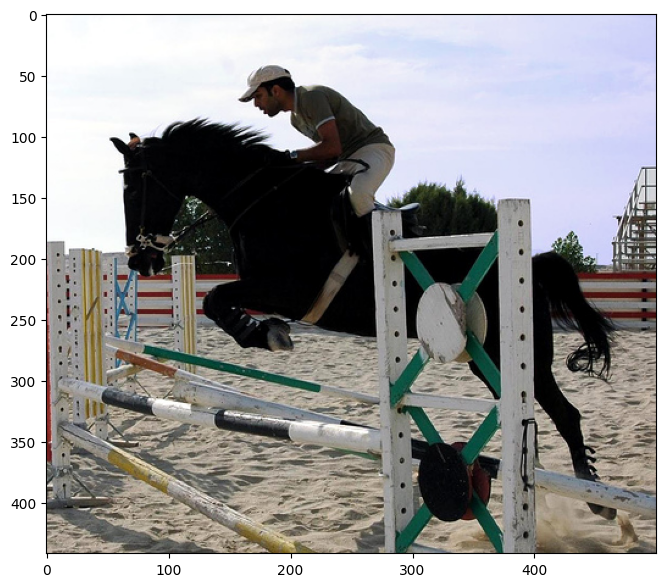

In [ ]:
print('Dimensionalidade:', dado.size())
dado, rotulo = coco[0]
dado = dado.permute(1, 2, 0) #jogar dimensão da imagem para o final

plt.figure(figsize=(8, 7) )
plt.imshow(dado)
plt.show()

In [ ]:
dado.size()

torch.Size([442, 500, 3])

In [ ]:
rotulo

{'annotation': {'folder': 'VOC2012',
  'filename': '2008_000008.jpg',
  'source': {'database': 'The VOC2008 Database',
   'annotation': 'PASCAL VOC2008',
   'image': 'flickr'},
  'size': {'width': '500', 'height': '442', 'depth': '3'},
  'segmented': '0',
  'object': [{'name': 'horse',
    'pose': 'Left',
    'truncated': '0',
    'occluded': '1',
    'bndbox': {'xmin': '53', 'ymin': '87', 'xmax': '471', 'ymax': '420'},
    'difficult': '0'},
   {'name': 'person',
    'pose': 'Unspecified',
    'truncated': '1',
    'occluded': '0',
    'bndbox': {'xmin': '158', 'ymin': '44', 'xmax': '289', 'ymax': '167'},
    'difficult': '0'}]}}

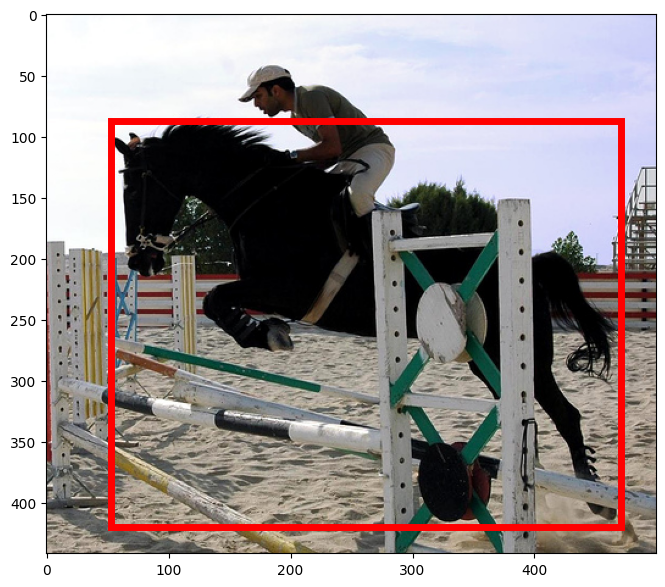

In [ ]:
bbox = rotulo['annotation']['object'][0]['bndbox']
xmax = int(bbox['xmax'])
xmin = int(bbox['xmin'])
ymax = int(bbox['ymax'])
ymin = int(bbox['ymin'])

fig, ax = plt.subplots(figsize=(8, 7))
plt.imshow(dado)

rect = patches.Rectangle((xmin, ymin), xmax-xmin , ymax-ymin, fill=False, linewidth=5, edgecolor='r')
ax.add_patch(rect)

plt.show()

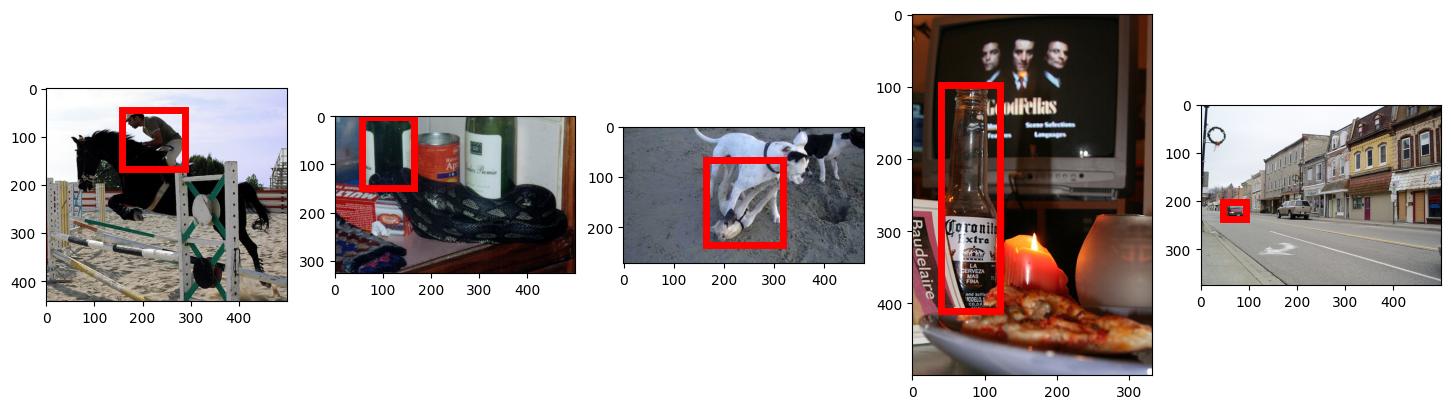

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(18, 7))
for i in range(5):
  dado, rotulo = coco[i]
  dado = dado.permute(1, 2, 0)

  bbox = rotulo['annotation']['object'][1]['bndbox']
  xmax = int(bbox['xmax'])
  xmin = int(bbox['xmin'])
  ymax = int(bbox['ymax'])
  ymin = int(bbox['ymin'])

  axs[i].imshow(dado)

  rect = patches.Rectangle((xmin, ymin), xmax-xmin , ymax-ymin, fill=False, linewidth=5, edgecolor='r')
  axs[i].add_patch(rect)

## Segmentação

In [ ]:
cocos = datasets.VOCSegmentation('./data',
                            image_set='train', download=True,
                            transform=transforms.ToTensor(),
                            target_transform=transforms.ToTensor())

In [ ]:
dado, rotulo = cocos[0]
print(type(dado), type(rotulo))
print(dado.size(), rotulo)

<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([3, 281, 500]) tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


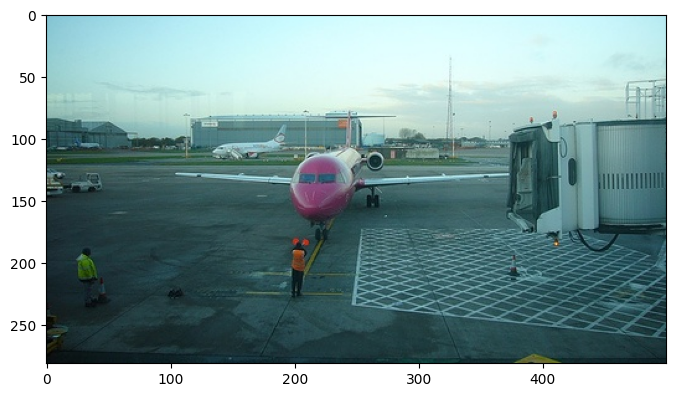

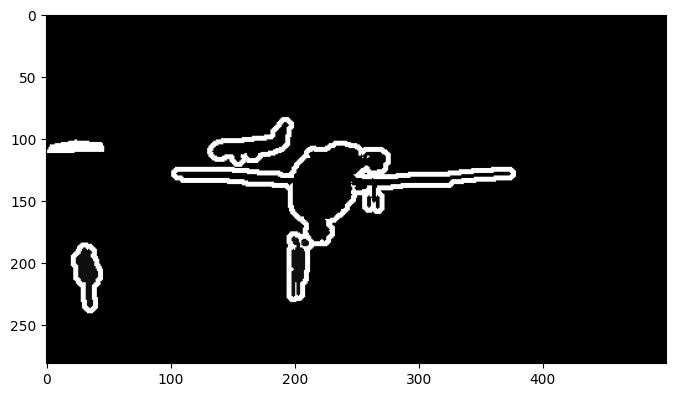

In [ ]:
dado = dado.permute(1,2,0)

plt.figure(figsize=(8, 7))
plt.imshow(dado)

plt.figure(figsize=(8, 7))
plt.imshow(rotulo[0], cmap='gray')
#rotulo é outra imagem mostrando a máscara do objeto

## Convolução 1D - Scipy

In [ ]:
from scipy.signal import convolve

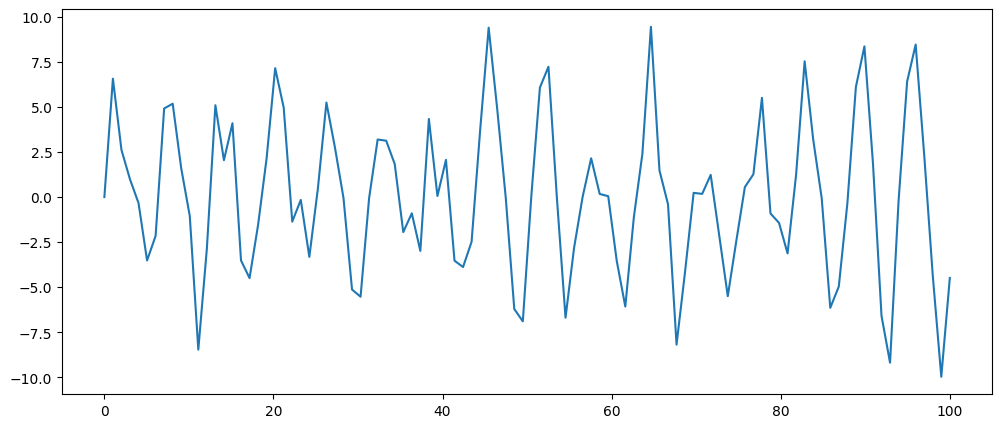

In [ ]:
x = np.linspace(0,100,100)
y = 10 * np.sin(x) * np.random.rand(x.shape[0])

plt.figure(figsize=(12,5))
plt.plot(x,y)

In [ ]:
def show(valores, title,):
  plt.figure(figsize=(len(valores), 2))
  plt.imshow(valores[np.newaxis, :], cmap='gray')
  for k, s in enumerate(valores):
    plt.text(k, 0, '{:.1f}'.format(s), fontsize=16, color='red', ha='center', va='center')
  plt.title(title, fontsize=18)
  plt.yticks([])

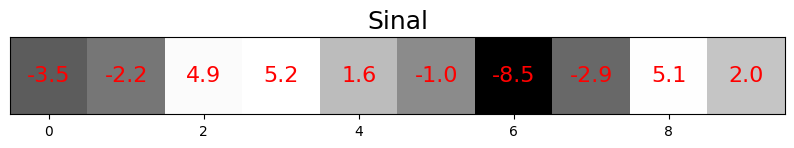

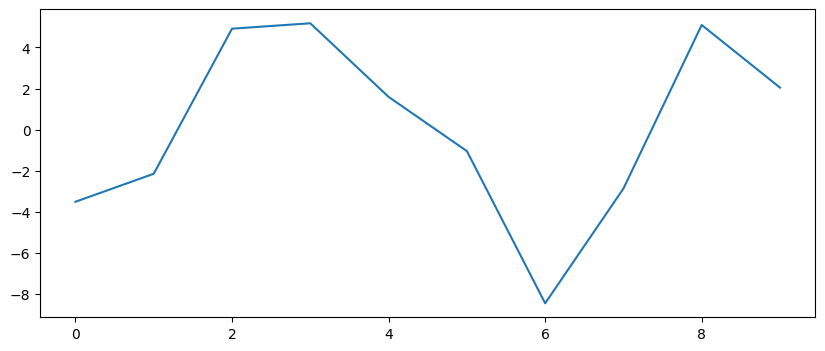

In [ ]:
sinal = y[5:15]

show(sinal, "Sinal")

plt.figure(figsize=(10,4))
plt.plot(sinal)

### Kernel

No contexto de processamento de imagens, o kernel é um **filtro convolucional**. De forma prática, é uma matriz n-dimensional que será operada com o dado através de uma convolução.

Pode-se dizer que a convolução **mede a semelhança** entre os dois sinais.

Precisamos portanto propor um kernel que simule o padrão procurado: intervalos crescentes.
> Mas lembre-se que a convolução opera as funções após **inverter o kernel**.

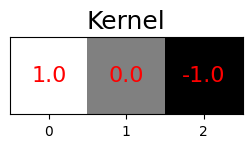

In [ ]:
kernel = np.asarray([1, 0, -1])
show(kernel, "Kernel")

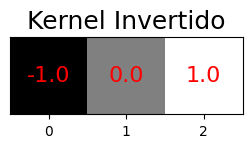

In [ ]:
kernel_inv = np.flip(kernel)
show(kernel_inv, "Kernel Invertido")

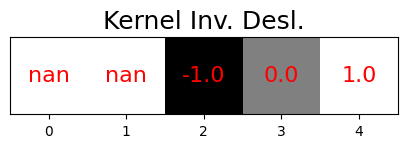

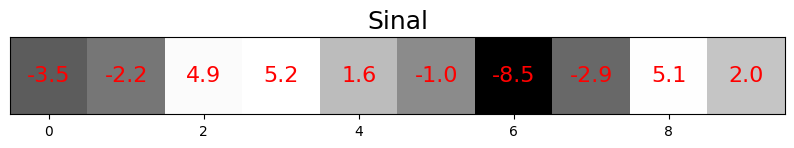

In [ ]:
plt.close('all')

## Vamos alterar o valor de u
## para deslocar o kernel
u=2
deslocamento = [float('nan')] * u
kernel_deslocado = np.hstack( (deslocamento, kernel_inv) )

show(kernel_deslocado, 'Kernel Inv. Desl.')
show(sinal, 'Sinal')

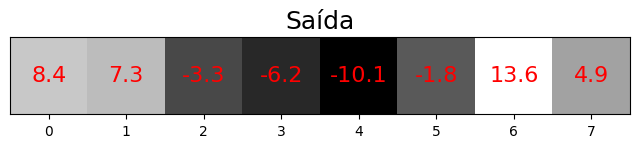

In [ ]:
out = convolve(sinal, kernel, mode='valid')
show(out, 'Saída')

Pra ficar mais visual, vamos imprimir a função resultante sobreposta ao sinal original, de modo a entender melhor como essa função nos ajuda a identificar os intervalos crescentes do sinal original.

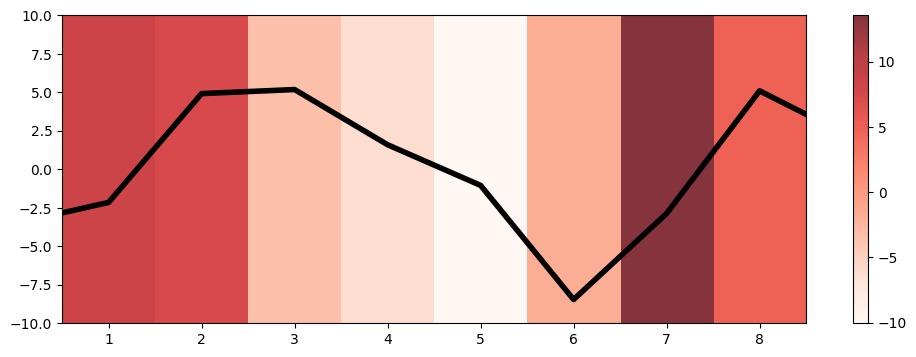

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(sinal, color='k', linewidth=4)
plt.imshow(out[np.newaxis, :], cmap='Reds', aspect='auto', alpha=0.8, extent=(0.5, 8.5, -10, 10))
plt.colorbar()

E se rodarmos no restante do sinal como uma espécie de classificação?<br>
Neste contexto específico, podemos considerar que **ativações menores que zero** indicam que não há tendência crescente naquele intervalo do sinal.

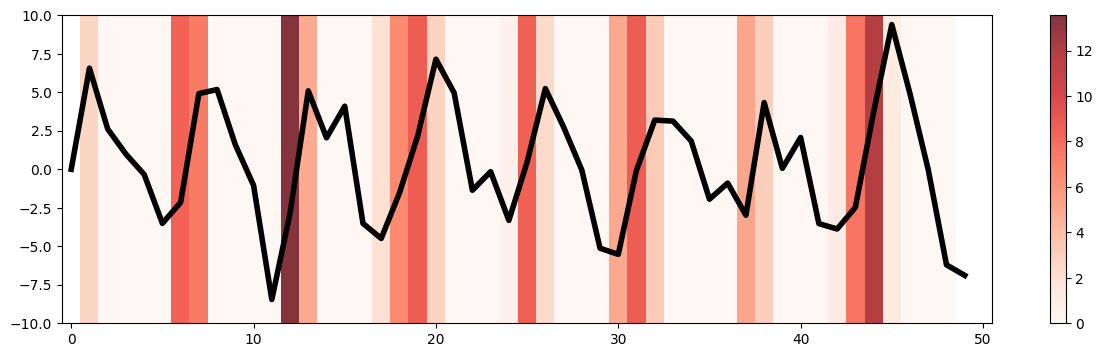

In [ ]:
out = convolve(y[:50], kernel, mode='valid')
out[out < 0] = 0

plt.figure(figsize=(15, 4))
plt.plot(y[:50], color='k', linewidth=4)
plt.imshow(out[np.newaxis, :], cmap='Reds', aspect='auto', alpha=0.8, extent=(0.5, 48.5, -10, 10))
plt.xlim(-0.5, 50.5)
plt.colorbar()

## Convolução 2D

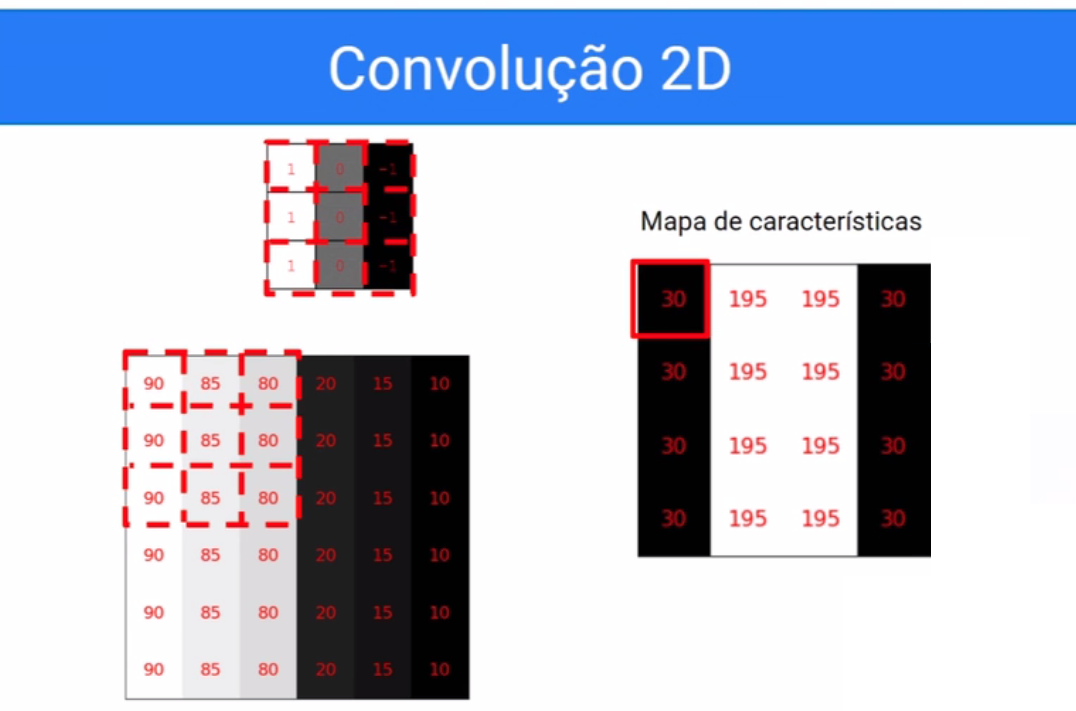

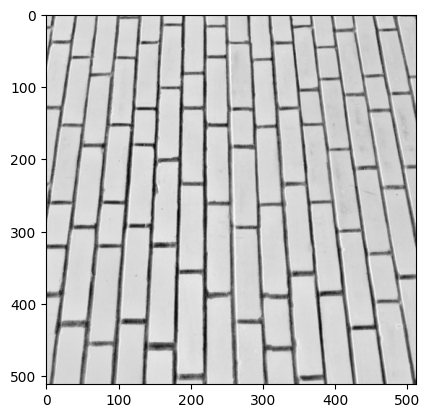

In [2]:
from skimage import io, color, transform, data

img = data.brick()
plt.imshow(img, cmap='Greys')

In [ ]:
def show(valores, title):
  plt.figure(figsize=(len(valores), len(valores) ))
  plt.imshow(valores, cmap='gray')
  for i, line in enumerate(valores):
    for j, col in enumerate(line):
      plt.text(j, i, '{:.0f}'.format(col), fontsize=16, color='red', ha='center', va='center')
  plt.title(title)
  plt.xticks([])
  plt.yticks([])
  plt.savefig(title+'.png', format='png', dpi=100, bbox_inches='tight')

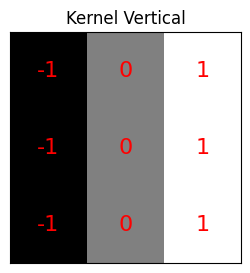

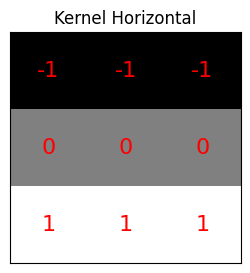

In [ ]:
kernel_v = [ [-1, 0, 1],
             [-1, 0, 1],
             [-1, 0, 1]]

show(kernel_v, 'Kernel Vertical')

kernel_h = [ [-1, -1, -1],
             [0, 0, 0],
             [1, 1, 1]]
show(kernel_h, 'Kernel Horizontal')

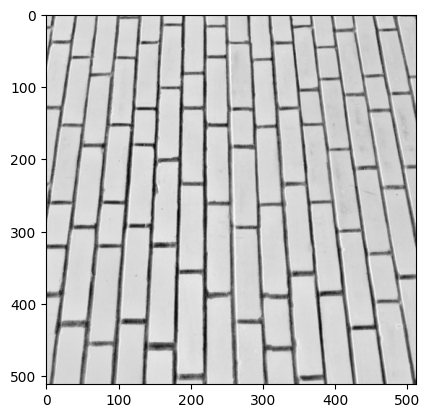

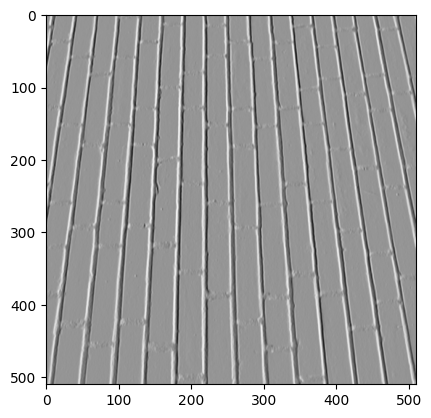

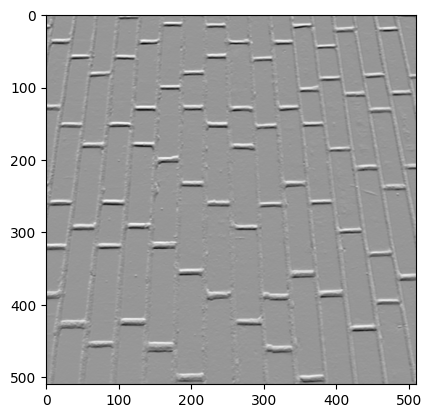

In [ ]:
mapa_de_caracteristicas = convolve(img, kernel_v, mode='valid')
plt.imshow(img, cmap='Greys')

plt.figure()
plt.imshow(mapa_de_caracteristicas, cmap='Greys')

mapa_de_caracteristicas = convolve(img, kernel_h, mode='valid')
plt.figure()
plt.imshow(mapa_de_caracteristicas, cmap='Greys')

### Uma observação sobre as ativações

Quando definimos o kernel, ele buscará o padrão para o qual foi definido, mas vale observar melhor o seu comportamento.
Vamos imprimir o kernel original, e a sua versão invertida que é de fato operada com a imagem durante a convolução.

In [ ]:
mapa_de_caracteristicas = convolve(img, kernel_v, mode='valid')
plt.imshow(img, cmap="Greys")

plt.figure()
plt.imshow(mapa_de_caracteristicas, cmap="Greys")

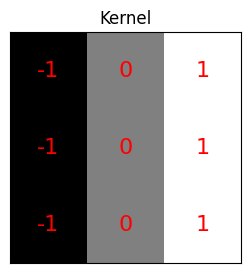

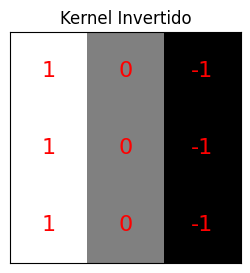

In [ ]:
show(kernel_v, 'Kernel')
show(np.flip(kernel_v), 'Kernel Invertido')

Vamos aplicar esse kernel a uma imagem que talvez você conheça. A logo de uma empresa de cursos online em tecnologia e marketing digital!

In [ ]:
!wget https://is5-ssl.mzstatic.com/image/thumb/Purple113/v4/a2/56/30/a2563080-dddc-6a02-9034-a461c6c02fae/AppIcon-0-1x_U007emarketing-0-0-85-220-0-10.png/1200x630wa.png

--2025-03-29 20:07:55--  https://is5-ssl.mzstatic.com/image/thumb/Purple113/v4/a2/56/30/a2563080-dddc-6a02-9034-a461c6c02fae/AppIcon-0-1x_U007emarketing-0-0-85-220-0-10.png/1200x630wa.png
Resolving is5-ssl.mzstatic.com (is5-ssl.mzstatic.com)... 151.101.3.6, 151.101.67.6, 151.101.131.6, ...
Connecting to is5-ssl.mzstatic.com (is5-ssl.mzstatic.com)|151.101.3.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30426 (30K) [image/png]
Saving to: ‘1200x630wa.png’

1200x630wa.png      100%[===================>]  29.71K  --.-KB/s    in 0.01s   

2025-03-29 20:07:56 (2.64 MB/s) - ‘1200x630wa.png’ saved [30426/30426]



Text(0.5, 1.0, 'Mapa de ativação')

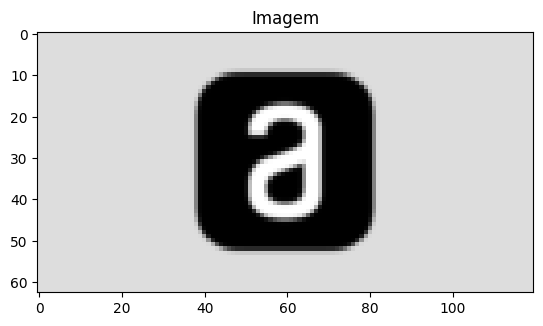

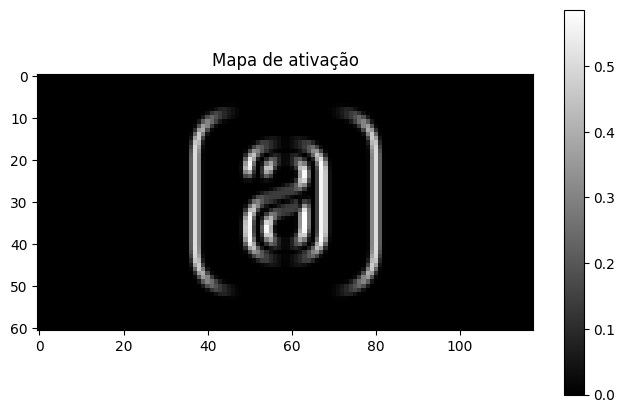

In [ ]:
img = io.imread('1200x630wa.png')
if img.shape[-1] == 4:
    img = img[..., :3]
img = color.rgb2gray(img)
img = transform.resize(img, (img.shape[0]//10, img.shape[1]//10) )

saida = convolve(img, kernel_v, 'valid')

plt.imshow(img, cmap='gray')
plt.title('Imagem')

plt.figure(figsize=(8, 5))
plt.imshow(np.abs(saida), cmap='gray')
plt.colorbar()
plt.title('Mapa de ativação')

Text(0.5, 1.0, 'Mapa de ativação')

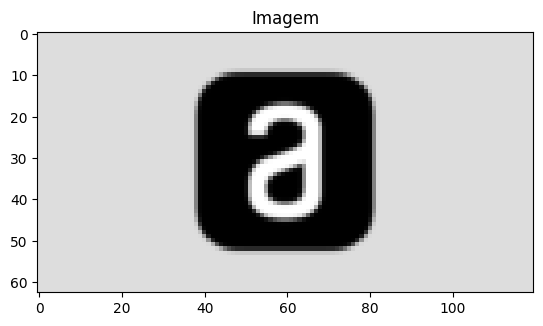

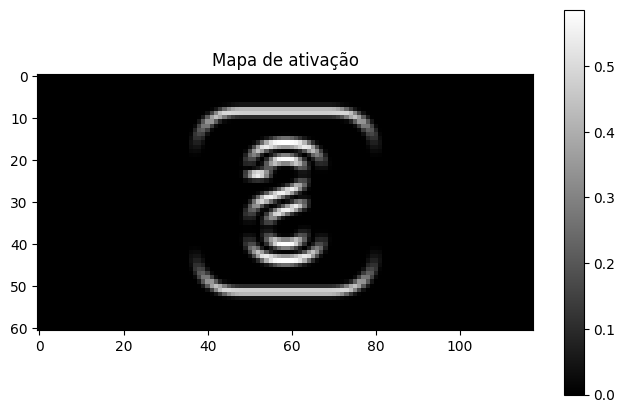

In [ ]:
img = io.imread('1200x630wa.png')
if img.shape[-1] == 4:
    img = img[..., :3]
img = color.rgb2gray(img)
img = transform.resize(img, (img.shape[0]//10, img.shape[1]//10) )

saida = convolve(img, kernel_h, 'valid')

plt.imshow(img, cmap='gray')
plt.title('Imagem')

plt.figure(figsize=(8, 5))
plt.imshow(np.abs(saida), cmap='gray')
plt.colorbar()
plt.title('Mapa de ativação')

## Filtros Convolucionais

In [ ]:
%matplotlib inline

Text(0.5, 1.0, 'Imagem')

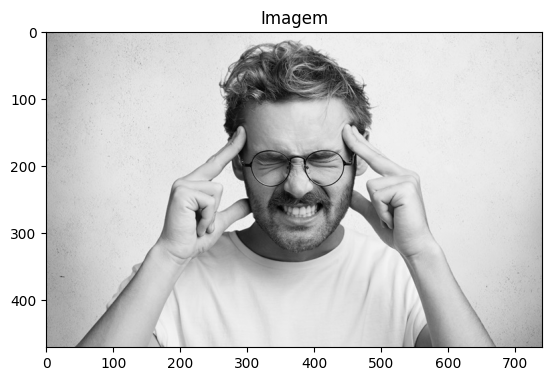

In [ ]:
img = io.imread('/content/people.jpg')

img_gray = color.rgb2gray(img)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagem')

In [ ]:
def show(img, kernel, resultado, titulo):
  fig, axs = plt.subplots(1, 3, figsize=(15, 5))
  plot = [img, kernel, resultado]
  titulos = ['Imagem', titulo, 'Mapa de Ativação']
  for k, ax in enumerate(axs):
    ax.imshow(plot[k], cmap='gray')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(titulos[k])

  for i, line in enumerate(kernel):
    for j, col in enumerate(line):
      axs[1].text(j, i, '{:.2f}'.format(col), fontsize=12, color='red', ha='center', va='center')

## Filtro da Média

Ao aplicar este filtro a uma imagem, o mapa de ativação resultante será uma versão suavizada da imagem original (mais "borrada", menos nítida). Este efeito é alcançado explorando a operação de convolução para **tirar a média dos pixels** de subregiões da imagem.

Os pesos desse kernel são definidos para replicar a operação da média, ou seja, para um filtro $3 \times 3$ com 9 pesos, temos que: <br><br>
\begin{equation}
\frac{\sum_{x=1}^{9} p(x)}{9} = \sum_{x=1}^{9} \frac{1}{9} p(x)
\end{equation}

Vamos modelar dois filtros:
* $3 \times 3$, com todos os pesos iguais a $\frac{1}{3^2}$

* $9 \times 9$, com todos os pesos iguais a $\frac{1}{9^2}$

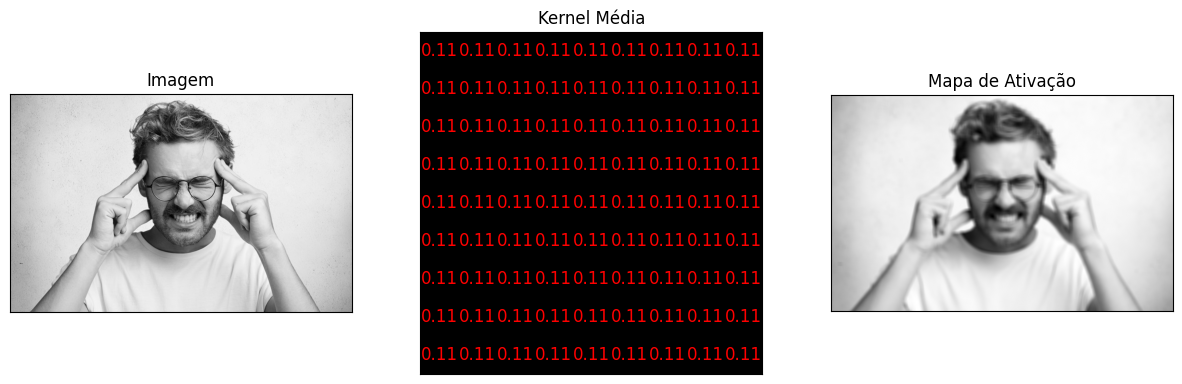

In [ ]:
kernel_media = np.zeros((9,9))
kernel_media [:] = 1.0/(3**2)

resultado = convolve(img_gray, kernel_media, mode="valid")
show(img_gray, kernel_media, resultado, "Kernel Média")

## Filtro de Sobel

Esse se parece muito com o filtro de bordas que já fizemos na aula passada, com a diferença que os vizinhos diretos do pixel central tem valor absoluto de maior intensidade (na horizontal ou na vertical, a depender da borda desejada).

> Após realizar a convolução, podemos imprimir os **valores absolutos** do mapa de ativação para visualizar as bordas independente do sinal da ativação.


[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


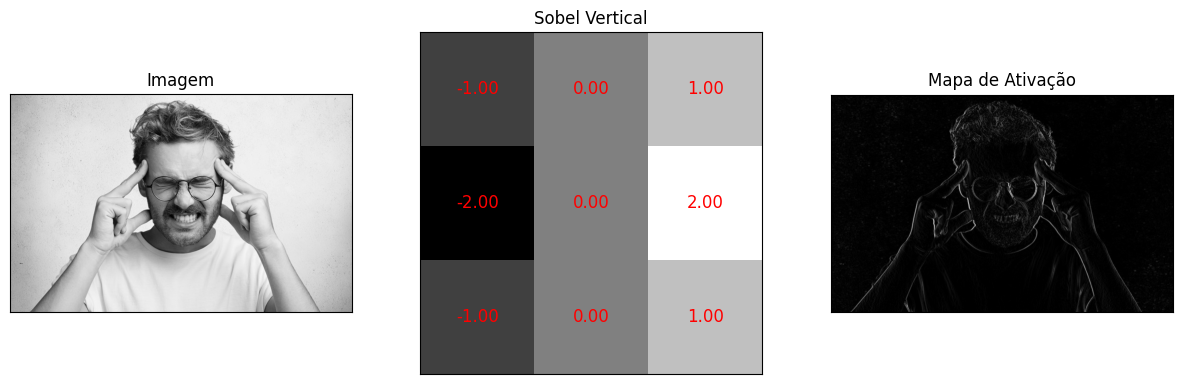

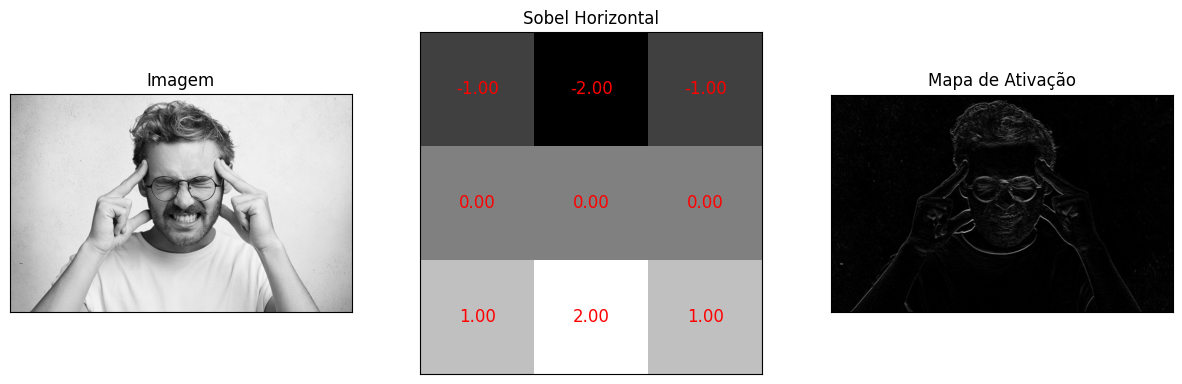

In [ ]:
##### SOBEL VERTICAL
sobel_v = np.zeros((3,3))
sobel_v[:, 0] = -1
sobel_v[:, 2] = 1
sobel_v[1, [0, 2]] = [-2, 2]
print(sobel_v)

resultado = convolve(img_gray, sobel_v, mode='valid')
show(img_gray, sobel_v, np.abs(resultado), 'Sobel Vertical')


##### SOBEL HORIZONTAL
sobel_h = np.zeros((3,3))
sobel_h[0, :] = -1
sobel_h[2, :] = 1
sobel_h[[0, 2], 1] = [-2, 2]
print()
print(sobel_h)

resultado = convolve(img_gray, sobel_h, mode='valid')
show(img_gray, sobel_h, np.abs(resultado), 'Sobel Horizontal')


## Filtro de Laplace

Por fim, vamos ver mais um filtro utilizado para detecção de bordas, o Laplace. Diferente do Sobel, este filtro destaca igualmente bordas de diferentes direções.

[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


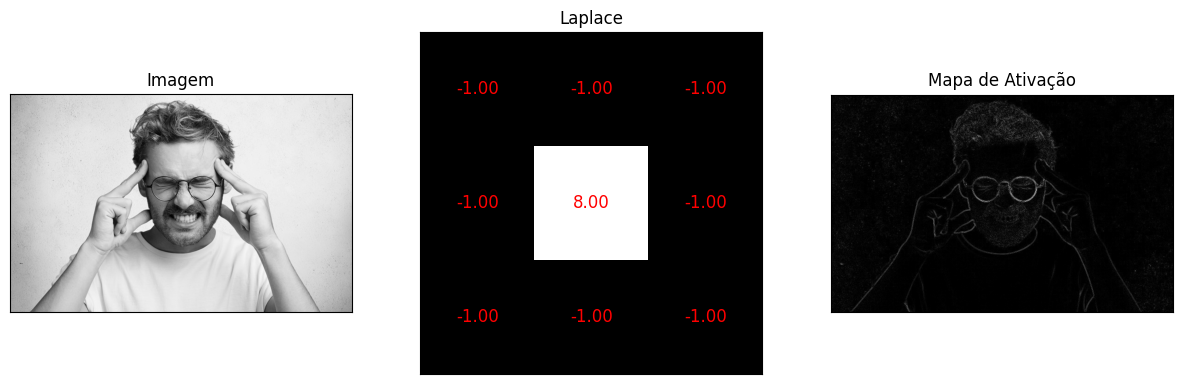

In [ ]:
laplace = np.ones((3,3)) * -1
laplace[1,1] = 8
print(laplace)

resultado = convolve(img_gray, laplace, mode="valid")
show(img_gray, laplace, np.abs(resultado), 'Laplace')

## Padrões Complexos

Para entender melhor como a convolução funciona como um casamento de padrões, vamos agora definir um filtro convolucional mais complexo, mas capaz de encontrar um casamento perfeito no dado.

In [ ]:
!wget https://www.dropbox.com/s/0nrix9eknyybuqk/image_2007_000032.jpg?dl=0
!mv image_2007_000032.jpg?dl=0 plane.jpg

--2025-03-29 20:39:53--  https://www.dropbox.com/s/0nrix9eknyybuqk/image_2007_000032.jpg?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/4bkbp9cta3rjw3qniyla3/image_2007_000032.jpg?rlkey=1d75pv8h17uzw8gyag4o67ksq&dl=0 [following]
--2025-03-29 20:39:53--  https://www.dropbox.com/scl/fi/4bkbp9cta3rjw3qniyla3/image_2007_000032.jpg?rlkey=1d75pv8h17uzw8gyag4o67ksq&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc597b84406bcd25e99c71ef3183.dl.dropboxusercontent.com/cd/0/inline/Cm2KKKeq0-Ng1RHD2mYwIbdvVU2NEaGMr873Qon1vW1vdVtQFwfsGqhNDGLqomaH0ehR8cnPr1QCNqam3dbeZYoU4Z-vFlEf_EEuaRzJ3O30pWo9WlkApWSsq8YYvBpHq-Y/file# [following]
--2025-03-29 20:39:53--  https://uc597b84406bcd25e99c71ef3183.dl.dropboxusercont

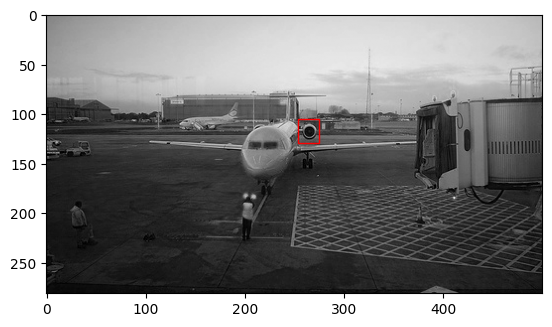

In [ ]:
#imprimi imagem e seleciona retangulo
img = io.imread('plane.jpg')
img = img[:,:,0]
retangulo = [105, 129, 253, 275]


#imprime imagem e retangulo
fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')
ax.add_patch(patches.Rectangle((retangulo[2], retangulo[0]),
                               (retangulo[3] - retangulo[2]),
                               (retangulo[1] - retangulo[0]), color='red', fill=False))

Para que o patch possa ser utilizado como filtro de convolução, precisamos:
* Subtrair o patch pelo valor do pixel médio (centralizando a distribuição)
* Inverter o filtro com a função ```flip``` do numpy.

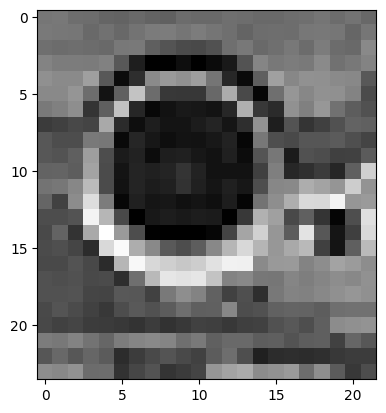

In [ ]:
patch = img[retangulo[0]:retangulo[1], retangulo[2]:retangulo[3]]
patch = patch - patch.mean()
patch = np.flip(patch)

plt.imshow(patch, cmap='gray')

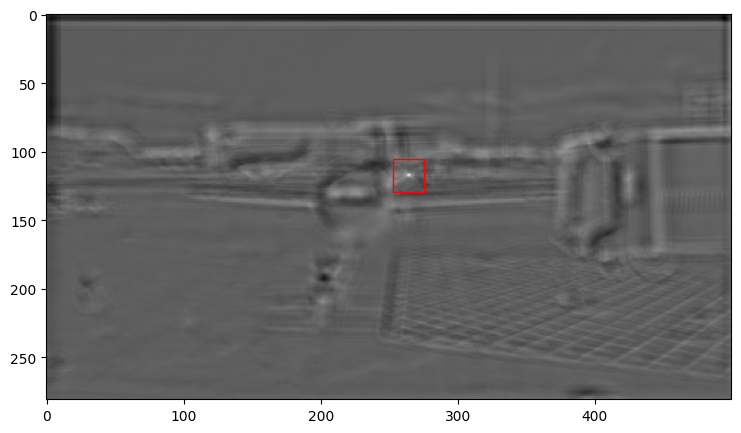

In [ ]:
resultado = convolve(img, patch, mode='same')

fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(resultado, cmap='gray')
ax.add_patch(patches.Rectangle((retangulo[2], retangulo[0]),
                               (retangulo[3] - retangulo[2]),
                               (retangulo[1] - retangulo[0]), color='red', fill=False))

Casamento perfeito entre kernel e ponto específico, pois kernel = ponto específico na imagem

## Múltiplos Canais

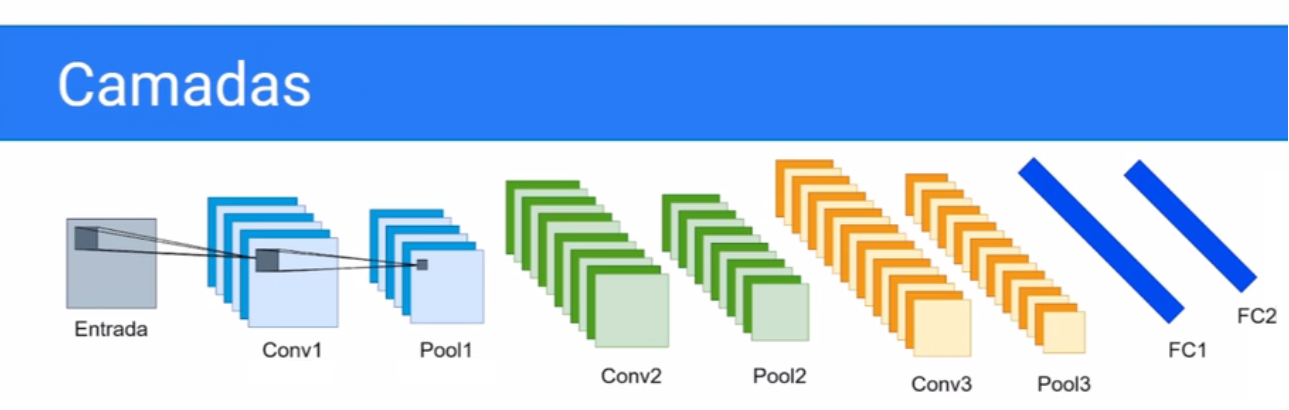

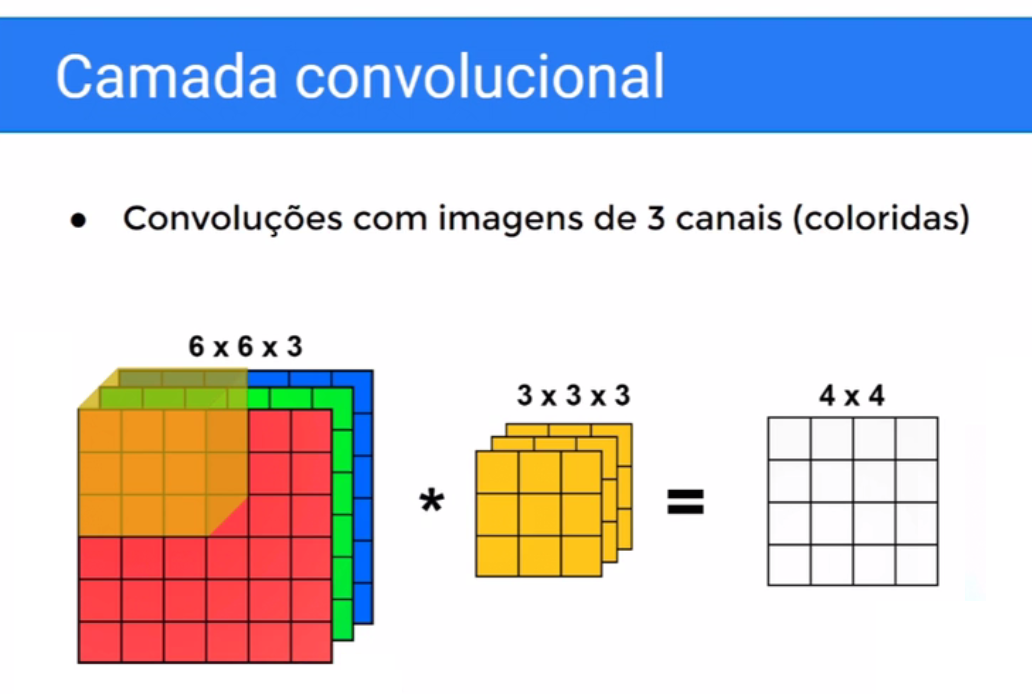

Quantos filtros convolucionais queremos em cada camada?

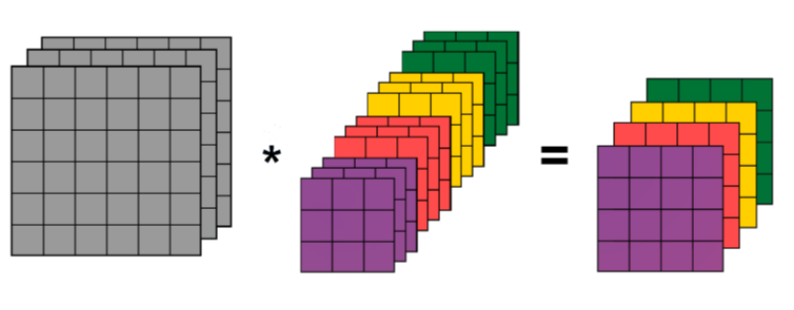

## implantando com pytorch

## Convolucional

Documentação: https://pytorch.org/docs/stable/nn.html#torch.nn.Conv2d

Começando pela operação principal, a convolução está contida na camada ```nn.Conv2d```. Dentre os parâmetros que ela recebe, vamos focar nos que já conhecemos, que já são suficientes para uma diversa gama de aplicações.

```python
torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
```

**```in_channels```**<br>
Assim como toda camada, seu primeiro parâmetro é referente ao **tamanho da entrada**. Não é necessário explicitar as 2 primeiras dimensões da entrada, apenas a profundidade, que corresponde à **quantidade de canais**.

**```out_channels```** <br>
Independentemente do número de canais de entrada, um único filtro convolucional terá como resultado um canal de saída. Alterando esse parâmetro estamos na verdade definindo o **número de filtros** que irão compor essa camada, interferindo na quantidade de neurônios dessa camada.

> Dica: Nas arquiteturas de redes neurais mais populares, aumentamos a dimensão do canal à medida que avançamos na rede neural, geralmente diminuindo a resolução.

**```kernel_size```** <br>
Tamanho dos filtros convolucionais. Pode ser uma tupla ou um único número. Ex: ```kernel_size = 3``` criará filtros $3 \times 3$

**```stride```** <br>
Controla o pulo da convolução ao longo da imagem.

**```padding```** <br>
Preenchimento com zeros nas bordas da imagem.

(512, 512) (512, 512, 3)


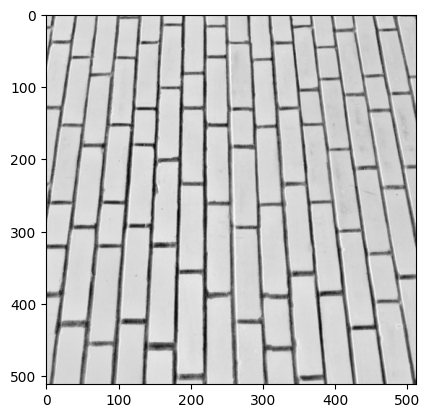

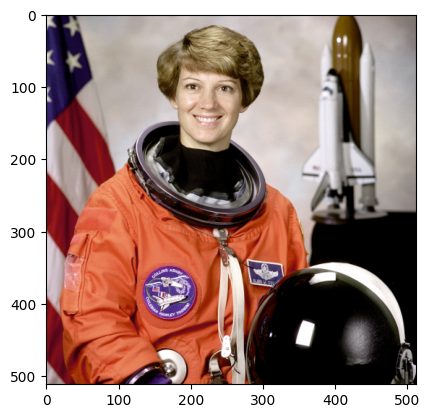

In [ ]:
# Stride: passo da janela deslizante
# in_channels: tamanho camada convolucional de entrada
# out_channels: tamanho camada convolucional de saída
# padding: adicionar bordas artificiais para preservar bordas originais

pb = data.brick()
rgb = data.astronaut()

print(pb.shape, rgb.shape)

plt.imshow(pb, cmap="Greys")
plt.figure()
plt.imshow(rgb)

Na célula a seguir vamos definir uma camada convolucional para realizar o forward na figura *brick*. Para isso, preste atenção em alguns detalhes:

* A entrada deve ser um dado tipo Tensor.
* A camada Convolucional espera uma entrada com as seguintes dimensões:
 $B \times C \times H \times W$

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=16,
                 kernel_size=3, stride=1, padding=1)

print(conv)

pb_tns = torch.Tensor(pb)
print(pb_tns.size())

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([512, 512])


In [ ]:
#transformar para tamanho do batch, num canais e tamanho
pb_tns = pb_tns.view(1, 1, pb_tns.size(0), pb_tns.size(1))
print(pb_tns.size())

torch.Size([1, 1, 512, 512])


In [ ]:
mapa_de_ativacao = conv(pb_tns)
print(mapa_de_ativacao.size())

torch.Size([1, 16, 512, 512])


In [ ]:
conv = nn.Conv2d(in_channels=3, out_channels=16,
                 kernel_size=5, padding=2)

print(conv)
rgb_tns = torch.Tensor(rgb)
rgb_tns = rgb_tns.permute(2, 0, 1).unsqueeze(0)
print(rgb_tns.size())

mapa_de_ativacao = conv(rgb_tns)
print(mapa_de_ativacao.size())

Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
torch.Size([1, 3, 512, 512])
torch.Size([1, 16, 512, 512])


## Pooling

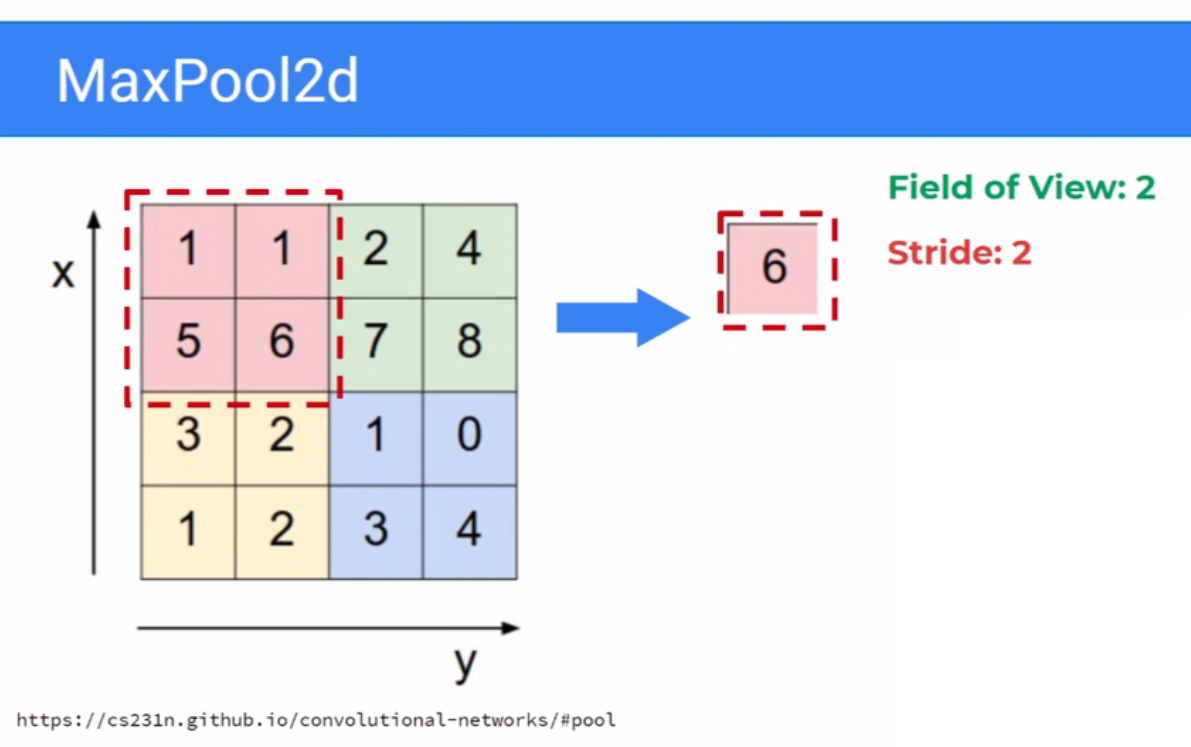

Documentação: https://pytorch.org/docs/stable/nn.html#torch.nn.MaxPool2d

```python
torch.nn.MaxPool2d(kernel_size, stride=None, padding=0)
```

**```kernel_size```** <br>
Tamanho dos *Field of View*. Pode ser uma tupla ou um único número. Ex: ```kernel_size = 3``` definirá FoV de $3 \times 3$

**```stride```** <br>
Controla o pulo da janela deslizante.

**```padding```** <br>
Preenchimento com zeros nas bordas da imagem.

A camada de pooling espera uma entrada de **pelo menos** 3 dimensões ($C \times H \times W$), mas em geral a rede irá prover também a dimensão do batch ($B \times C \times H \times W$)

In [9]:
tns = torch.FloatTensor([[[1,2,3],
                         [4,5,6],
                         [7,8,9]]])

pool = nn.MaxPool2d(kernel_size=2, stride=1)
output = pool(tns)
print(tns.size())
print("\n", output.size(), "\n")
print(tns , "\n\n" , output)

torch.Size([1, 3, 3])

 torch.Size([1, 2, 2]) 

tensor([[[1., 2., 3.],
         [4., 5., 6.],
         [7., 8., 9.]]]) 

 tensor([[[5., 6.],
         [8., 9.]]])


In [11]:
conv = nn.Conv2d(in_channels=3, out_channels=16,
                 kernel_size=3, stride=1, padding=1)

rgb = data.astronaut()
rgb_tns = torch.Tensor(rgb)
rgb_tns = rgb_tns.permute(2,0,1).unsqueeze(0)
mapa_de_ativacao = conv(rgb_tns)
print(mapa_de_ativacao.shape)

torch.Size([1, 16, 512, 512])


## Batch Normalization

Documentação: https://pytorch.org/docs/stable/nn.html#torch.nn.BatchNorm2d

```python
torch.nn.BatchNorm2d(num_features)
```

**```num_features```**<br>
$\mathbf{\gamma}$ e $\mathbf{\beta}$ são aprendidos individualmente para cada canal da entrada. Em ativações de camadas intermediárias, esse valor corresponde ao **número de feature maps**.

In [14]:
blococonv = nn.Sequential(
            nn.Conv2d(3,32, kernel_size=3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=10)
)

print(blococonv)
print(rgb_tns.size())
output = blococonv(rgb_tns)
print(output.size())


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=10, stride=10, padding=0, dilation=1, ceil_mode=False)
)
torch.Size([1, 3, 512, 512])
torch.Size([1, 32, 51, 51])


In [15]:
blococonv = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=10)
)
print(blococonv)

minibatch = torch.cat(12*[rgb_tns]) #concatenar o mesmo tensor várias vezes

print(minibatch.size())
saida = blococonv(minibatch)
print(saida.size())

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=10, stride=10, padding=0, dilation=1, ceil_mode=False)
)
torch.Size([12, 3, 512, 512])
torch.Size([12, 32, 51, 51])


## Passos importantes

* Representação numérica de uma imagem
* Motivação do uso de redes neurais convolucionais (CNN)
* Representações visuais de uma CNN
* Principais usos da CNN
* Datasets do Torchvision
* Definição da operação Convolução
* Kernels para Convolução 1D
* Convolução com a biblioteca scipy
* Uso da convolução para Reconhecimento de Padrões
* Operação da Convolução 2D
* Kernels 2D
* Exemplos de filtros manualmente projetados
* Casamento de padrões complexos
* Convolução com imagens RGB
* Parâmetros da Convolução
* Controle de resolução da informação
* Definindo uma convolução no PyTorch
* Camada de Pooling
* Visualizando ativações hierárquicas
* Camada de Batch Normalization
* Implementação de um bloco convolucional em PyTorch